First 5 rows:
    CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


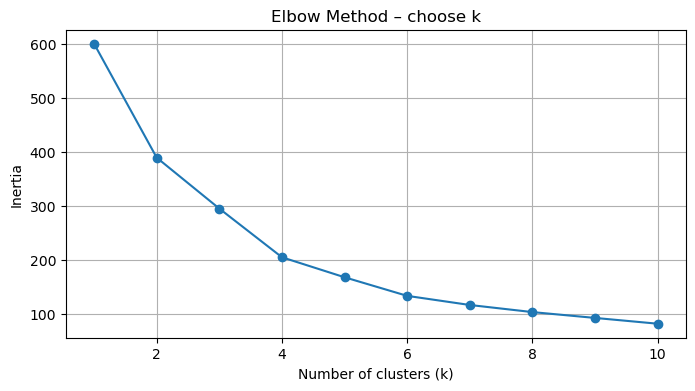

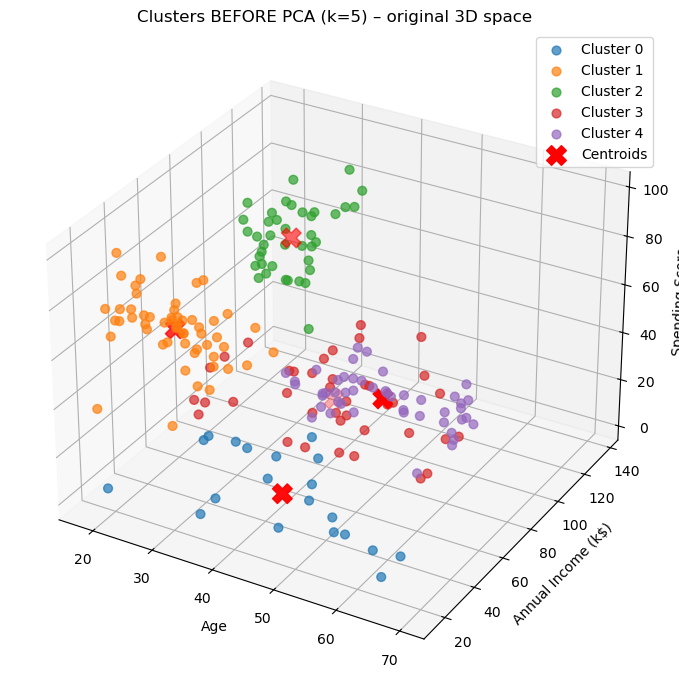

Explained variance ratios: [0.44266167 0.33308378]
Total variance explained: 0.7757


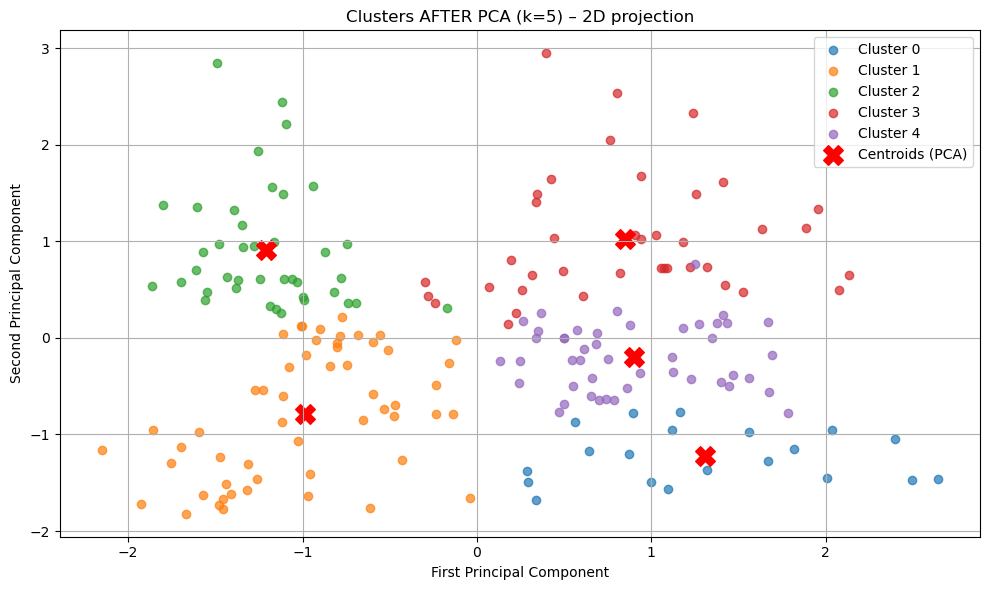


Cluster average features:
               Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                       
0        46.250000           26.750000               18.350000
1        25.185185           41.092593               62.240741
2        32.875000           86.100000               81.525000
3        39.871795           86.102564               19.358974
4        55.638298           54.382979               48.851064


In [1]:
#import os
#os.environ["OMP_NUM_THREADS"] = "1"
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D  # for 3D plotting

# ---------------------------
# 1. Load dataset
# ---------------------------
df = pd.read_csv('Customers_Data.csv')
print("First 5 rows:\n", df.head())

# ---------------------------
# 2. Select features and scale
# ---------------------------
features = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
X = df[features].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ---------------------------
# 3. Determine optimal k (elbow method)
# ---------------------------
inertia = []
K_range = range(1, 11)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,4))
plt.plot(K_range, inertia, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method – choose k')
plt.grid(True)
plt.show()

k_optimal = 5   # typical elbow point

# ---------------------------
# 4. Apply K-Means on the original scaled data (3D)
# ---------------------------
kmeans = KMeans(n_clusters=k_optimal, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)
df['Cluster'] = clusters

# ---------------------------
# 5. Visualisation BEFORE PCA (in original 3D space)
# ---------------------------
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Get the original (unscaled) data for plotting axes in meaningful units
X_original = X  # (Age, Income, Spending)

for cluster in range(k_optimal):
    mask = clusters == cluster
    ax.scatter(X_original[mask, 0], X_original[mask, 1], X_original[mask, 2],
               label=f'Cluster {cluster}', alpha=0.7, s=40)

# Plot centroids (in original scale)
centroids_scaled = kmeans.cluster_centers_
centroids_original = scaler.inverse_transform(centroids_scaled)
ax.scatter(centroids_original[:, 0], centroids_original[:, 1], centroids_original[:, 2],
           marker='X', s=200, c='red', label='Centroids')

ax.set_xlabel('Age')
ax.set_ylabel('Annual Income (k$)')
ax.set_zlabel('Spending Score')
ax.set_title(f'Clusters BEFORE PCA (k={k_optimal}) – original 3D space')
ax.legend()
plt.tight_layout()
plt.show()

# ---------------------------
# 6. Apply PCA to reduce to 2 components
# ---------------------------
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(f"Explained variance ratios: {pca.explained_variance_ratio_}")
print(f"Total variance explained: {sum(pca.explained_variance_ratio_):.4f}")

# ---------------------------
# 7. Visualisation AFTER PCA (in 2D PC space)
# ---------------------------
plt.figure(figsize=(10, 6))
for cluster in range(k_optimal):
    mask = clusters == cluster
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                label=f'Cluster {cluster}', alpha=0.7)

# Project centroids into PCA space
centroids_pca = pca.transform(centroids_scaled)
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1],
            marker='X', s=200, c='red', label='Centroids (PCA)')

plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
plt.title(f'Clusters AFTER PCA (k={k_optimal}) – 2D projection')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ---------------------------
# 8. (Optional) Cluster summaries
# ---------------------------
print("\nCluster average features:")
print(df.groupby('Cluster')[features].mean())